In [2]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)


In [3]:
from sklearn.datasets import load_iris
help(load_iris)

Help on function load_iris in module sklearn.datasets._base:

load_iris(*, return_X_y=False, as_frame=False)
    Load and return the iris dataset (classification).

    The iris dataset is a classic and very easy multi-class classification
    dataset.

    =================   ==============
    Classes                          3
    Samples per class               50
    Samples total                  150
    Dimensionality                   4
    Features            real, positive
    =================   ==============

    Read more in the :ref:`User Guide <iris_dataset>`.

    .. versionchanged:: 0.20
        Fixed two wrong data points according to Fisher's paper.
        The new version is the same as in R, but not as in the UCI
        Machine Learning Repository.

    Parameters
    ----------
    return_X_y : bool, default=False
        If True, returns ``(data, target)`` instead of a Bunch object. See
        below for more information about the `data` and `target` object.

 

In [4]:
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [5]:
iris["data"].shape

(150, 4)

In [6]:
# Första fem raderna i "data"
print(iris['data'][:5])

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [7]:
iris["target"].shape

(150,)

In [8]:
iris["target"][:10]

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: target, dtype: int64

In [9]:
iris["feature_names"]

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [10]:
iris["target_names"]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [11]:
iris['DESCR']

'.. _iris_dataset:\n\nIris plants dataset\n--------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 150 (50 in each of three classes)\n:Number of Attributes: 4 numeric, predictive attributes and the class\n:Attribute Information:\n    - sepal length in cm\n    - sepal width in cm\n    - petal length in cm\n    - petal width in cm\n    - class:\n            - Iris-Setosa\n            - Iris-Versicolour\n            - Iris-Virginica\n\n:Summary Statistics:\n\n============== ==== ==== ======= ===== ====================\n                Min  Max   Mean    SD   Class Correlation\n============== ==== ==== ======= ===== ====================\nsepal length:   4.3  7.9   5.84   0.83    0.7826\nsepal width:    2.0  4.4   3.05   0.43   -0.4194\npetal length:   1.0  6.9   3.76   1.76    0.9490  (high!)\npetal width:    0.1  2.5   1.20   0.76    0.9565  (high!)\n============== ==== ==== ======= ===== ====================\n\n:Missing Attribute Values: None\n:Class Distribution: 

In [12]:
print(iris["data_module"])
print(iris["filename"])

sklearn.datasets.data
iris.csv


## Insert it to a dataframe using as_frame=True

In [13]:
import pandas as pd

df = iris.frame
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


## EDA

In [14]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [16]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [17]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

In [18]:
df["target"].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [19]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

### Make a correlation heatmap to see how each feature is correlated to each other. What do the numbers mean?


Droppa target och spara features

In [20]:
df_features = iris.frame.drop(columns="target")
df_features

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [21]:
corr = df_features.corr()
print(corr)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


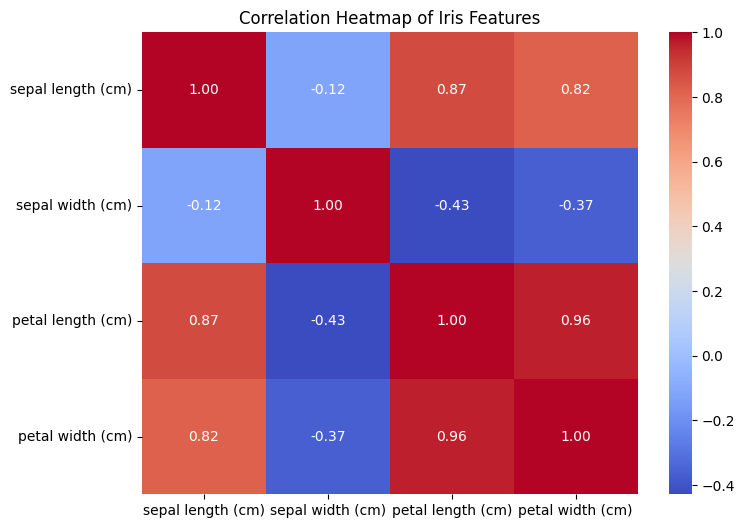

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Iris Features")
plt.show()


## Tolka datan
- om sl är högt är också pl högt
- om sl är högt är också pw högt


### Make a boxplot. The points outside of the boxplot are statistically calculated outliers using Tukey's rule for boxplot.

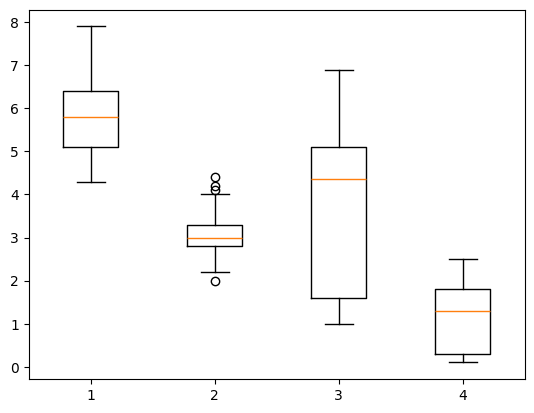

In [23]:
import matplotlib.pyplot as plt

plt.boxplot(df_features)
plt.show()

### Använd pandas när jag ska sortera bort outliers

Now remove the outliers in data. (**):

Lower bound outlier: Q1 - 1.5 x IQR
Upper bound outlier: Q3 + 1.5 x IQR

where   Q1 is the 1st quartile or 25 percentile,
        Q3 is the 3rd quartile or 75 percentile 
        and IQR=Q3−Q1 is the interquartile range

In [24]:
import pandas as pd

# Hämta ut kvartil
Q1 = df_features["sepal width (cm)"].quantile(0.25)
Q3 = df_features["sepal width (cm)"].quantile(0.75)
IQR = Q3 - Q1 #interquartal range

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_without_outliers = df[(df["sepal width (cm)"] >= lower_bound) & (df["sepal width (cm)"] <= upper_bound)]

lower_bound, upper_bound

(np.float64(2.05), np.float64(4.05))

In [25]:
(df["sepal width (cm)"] >= lower_bound).sum()
(df["sepal width (cm)"] <= upper_bound).sum()

np.int64(147)

In [26]:
df_without_outliers

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


###   g) Do train|test split on the dataset and then scale it with feature standardization.



In [27]:
X, y = df_without_outliers.drop("target", axis="columns"), df_without_outliers["target"]
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [28]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.33, random_state=42)

## RANDOM FOREST

Ingen skalning

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier()

model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)
antal_fel = y_pred[:10] - y_test[:10].values
print(antal_fel)

[0 0 0 0 0 0 0 0 1 0]


In [47]:
y_test[:10].values

array([0, 2, 0, 0, 0, 2, 0, 1, 1, 0])

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.91      0.91      0.91        11
           2       0.95      0.95      0.95        19

    accuracy                           0.96        49
   macro avg       0.95      0.95      0.95        49
weighted avg       0.96      0.96      0.96        49



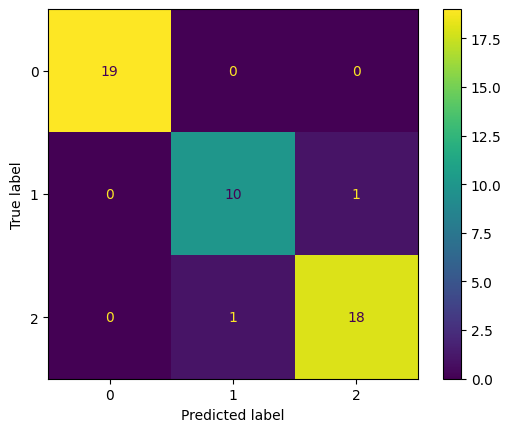

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report

print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_test = scaler.transform(X_test)

scaled_X_train.std(), scaled_X_train.mean(), scaled_X_test.std(), scaled_X_test.mean()


(np.float64(0.9999999999999998),
 np.float64(2.998746726307124e-16),
 np.float64(0.9999349444958894),
 np.float64(-0.026200181679167715))

###   h) Classify using logistic regression



In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty=None)
model.fit(scaled_X_train, y_train)
model.coef_, model.intercept_

(array([[-3.8037175 ,  3.96884509, -7.59732281, -6.8800107 ],
        [ 2.99581147, -1.06640654, -2.960846  , -0.74602156],
        [ 0.80790603, -2.90243855, 10.55816881,  7.62603225]]),
 array([-2.53649742,  7.9554134 , -5.41891598]))

In [33]:
test_sample = pd.DataFrame(
    {"sepal length (cm)": [1.2], "sepal width (cm)": [1.6], "petal length (cm)": [3.4], "petal width (cm)": [4.1]}
)

test_sample


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,1.2,1.6,3.4,4.1


In [34]:
## Borde vara 0 - setosa

scaled_test_sample = scaler.transform(test_sample)

model.predict_proba(scaled_test_sample)

array([[7.04456938e-22, 1.18430533e-15, 1.00000000e+00]])

In [35]:
# Kontrollera så att det var en setosa
y_test

48     0
101    2
28     0
20     0
45     0
124    2
30     0
84     1
70     1
19     0
12     0
119    2
145    2
82     1
141    2
39     0
64     1
143    2
31     0
58     1
100    2
126    2
11     0
71     1
34     0
97     1
68     1
105    2
118    2
9      0
4      0
27     0
127    2
132    2
17     0
10     0
142    2
88     1
72     1
54     1
139    2
138    2
115    2
0      0
121    2
137    2
29     0
43     0
108    2
Name: target, dtype: int64

In [36]:
## Borde t aut en från testdatan i stället
X_test

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
48,5.3,3.7,1.5,0.2
101,5.8,2.7,5.1,1.9
28,5.2,3.4,1.4,0.2
20,5.4,3.4,1.7,0.2
45,4.8,3.0,1.4,0.3
124,6.7,3.3,5.7,2.1
30,4.8,3.1,1.6,0.2
84,5.4,3.0,4.5,1.5
70,5.9,3.2,4.8,1.8
19,5.1,3.8,1.5,0.3


 Classify the first 10 values of your Xtest and compare it manually with your labels.

In [37]:
# Predicta de första 10 raderna i test
y_pred_10 = model.predict(scaled_X_test[:10])

In [38]:
# Riktiga värdena (labels)
y_true = y_test[:10].values

## LINEAR REGRESSION 0 fel

In [52]:
print(y_pred_10 - y_true)

[0 0 0 0 0 0 0 0 0 0]


In [39]:
# Skapa en dataframe med facit och predictions
compare = pd.DataFrame({"y_true": y_true, "y_pred": y_pred_10})

print(compare)

   y_true  y_pred
0       0       0
1       2       2
2       0       0
3       0       0
4       0       0
5       2       2
6       0       0
7       1       1
8       1       1
9       0       0


## j) Evaluate your model using classification report and confusion matrix.

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_true, y_pred_10))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



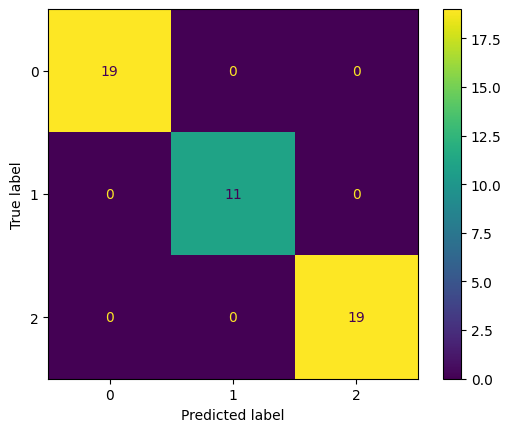

In [41]:
y_pred = model.predict(scaled_X_test)

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

## Use KNN to classify iris dataset

In [42]:
from sklearn.neighbors import KNeighborsClassifier

model_KN = KNeighborsClassifier(n_neighbors=3)
model_KN.fit(scaled_X_train, y_train)

y_pred_KN = model_KN.predict(scaled_X_test)
y_pred_KN

array([0, 2, 0, 0, 0, 2, 0, 1, 1, 0, 0, 1, 2, 1, 2, 0, 1, 2, 0, 1, 2, 2,
       0, 1, 0, 1, 1, 2, 2, 0, 0, 0, 2, 2, 0, 0, 2, 1, 2, 1, 2, 1, 2, 0,
       2, 2, 0, 0, 2])

In [43]:
y_test.values

array([0, 2, 0, 0, 0, 2, 0, 1, 1, 0, 0, 2, 2, 1, 2, 0, 1, 2, 0, 1, 2, 2,
       0, 1, 0, 1, 1, 2, 2, 0, 0, 0, 2, 2, 0, 0, 2, 1, 1, 1, 2, 2, 2, 0,
       2, 2, 0, 0, 2])

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.83      0.91      0.87        11
           2       0.94      0.89      0.92        19

    accuracy                           0.94        49
   macro avg       0.93      0.93      0.93        49
weighted avg       0.94      0.94      0.94        49



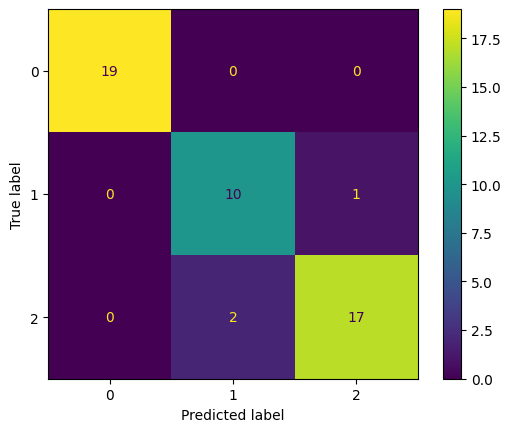

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report

print(classification_report(y_test,y_pred_KN))

cm = confusion_matrix(y_test, y_pred_KN)
ConfusionMatrixDisplay(cm).plot()